In [1]:
from matplotlib.animation import FuncAnimation
import numpy as np
import matplotlib.pyplot as plt


### Load In pre calculated Counts

In [2]:

def load_count(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
        masked_outputs = eval(','.join([line.strip() for line in lines]))
    data = {'cy5' : [], 'taggfp' : [], 'mkate' : [], 'taggfp + mkate' : []}


    for (taggfp, mkate, cy5, taggfp_mkate) in masked_outputs:
        data['taggfp'].append(taggfp)
        data['mkate'].append(mkate)
        data['cy5'].append(cy5)
        data['taggfp + mkate'].append(taggfp_mkate)
    

    timepoints = np.arange(len(data['cy5']))
    timepoints_shifted = timepoints*20
    return data, timepoints

data1, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Negative_Controls_1_counts.txt')
data2, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Negative_Controls_2_counts.txt')
data3, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Negative_Controls_3_counts.txt')

merged = {}
for key in data1:
    list1 = data1[key]
    list2 = data2[key]
    list3 = data3[key]

    averaged_list = []
    for i in range(len(list1)):
        avg = (list1[i] + list2[i] + list3[i]) / 3
        averaged_list.append(avg)
    merged[key] = averaged_list

merged_controls = merged.copy()

data1, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Myod_1_counts.txt')
data2, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Myod_2_counts.txt')

merged = {}
for key in data1:
    list1 = data1[key]
    list2 = data2[key]

    averaged_list = []
    for i in range(len(list2)):
        avg = (list1[i] + list2[i]) / 2
        averaged_list.append(avg)
    merged[key] = averaged_list


merged_myod = merged.copy()


data1, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Myod_PRRX1_1_counts.txt')
data2, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Myod_PRRX1_2_counts.txt')
data2, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/Myod_PRRX1_3_counts.txt')

merged = {}
for key in data1:
    list1 = data1[key]
    list2 = data2[key]
    list3 = data3[key]

    averaged_list = []
    for i in range(len(list1)):
        avg = (list1[i] + list2[i] + list3[i]) / 3
        averaged_list.append(avg)
    merged[key] = averaged_list

merged_myod_prrx = merged.copy()


data1, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/PRRX1_1_counts.txt')
# data2, timepoints = load_count('/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/data/PRRX1_2_counts.txt')

merged = {}
for key in data1:
    list1 = data1[key]
    list2 = data2[key]

    averaged_list = []
    for i in range(len(list2)):
        avg = (list1[i] + list2[i]) / 2
        averaged_list.append(avg)
    merged[key] = averaged_list


merged_prrx = data1.copy()




In [7]:
# masked counts
data = merged

def update_plot(data, condition):
        
    ### Updating animation
    taggfp_percent = []
    mkate_percent = []
    taggfp_plus_mkate_percent = []
    
    for i in range(len(data['cy5'])):
        taggfp_percent.append((data['taggfp'][i]/data['cy5'][i])*100)
        mkate_percent.append((data['mkate'][i]/data['cy5'][i])*100)
        taggfp_plus_mkate_percent.append((data['taggfp + mkate'][i]/data['cy5'][i])*100)
    
    window_size = 7
    taggfp_smoothed = np.convolve(taggfp_percent, np.ones(window_size)/window_size, mode='valid')
    mkate_smoothed = np.convolve(mkate_percent, np.ones(window_size)/window_size, mode='valid')
    taggfp_plus_mkate_smoothed = np.convolve(taggfp_plus_mkate_percent, np.ones(window_size)/window_size, mode='valid')
    
    
    totlen = len(taggfp_smoothed)
    
        
    for i in range(totlen-1, totlen):
    
        taggfp_cur = taggfp_smoothed[:i]
        mkate_cur = mkate_smoothed[:i]
        taggfp_plus_mkate_cur = taggfp_plus_mkate_smoothed[:i]
    
        print(len(taggfp_percent), len(taggfp_smoothed))
        taggfp_percent_cur = taggfp_percent[:i]
        mkate_percent_cur = mkate_percent[:i]
        taggfp_plus_mkate_percent_cur = taggfp_plus_mkate_percent[:i]
    
        time_cur = timepoints[:i]
        print(len(taggfp_percent_cur), len(time_cur))
        
        # [
        #     "#5e4fa2",  # Deep purple
        #     "#7b68b0",  # Medium purple
        #     "#9988bf",  # Light lavender
        #     "#bfa7b7",  # Mauve / bridge color
        #     "#d88e6b",  # Orange-tan
        #     "#e07b45",  # Warm orange
        #     "#f46d43",  # Bright orange
        # ]
        
        # taggfp_color = '#58eb34'
        # mkate_color = '#ff5962'
        # taggfp_plus_mkate_color = '#ffec17'
        
        
        taggfp_color = '#5e4fa2'
        mkate_color = '#bfa7b7'
        taggfp_plus_mkate_color = '#f46d43'
        facecolor = 'white'
        plotwidth = 5
        outlinewidth = 2
        
        
        
        # taggfp_color = 'green'
        # mkate_color = 'red'
        # taggfp_plus_mkate_color = 'yellow'
        
        
        plt.style.use('default')
        plt.figure(facecolor='white', figsize=(17, 5))
        # ax.set_facecolor(facecolor)
        # plt.xlabel("Timepoints")
        # plt.ylabel("Total Number of Cells (%)")
        # plt.title("Cell count Percentage over time in each phase")
        plt.legend()
        # plt.grid(True)
        plt.grid(linewidth=0.3)
        plt.xlim(0, 180)
        plt.ylim(40, 100)
        plt.tick_params(axis='x', labelbottom=False)  # Hides tick labels
        ax = plt.gca()  # Get current axis

        ax.spines['top'].set_linewidth(outlinewidth)  # Increase top border thickness
        ax.spines['right'].set_linewidth(outlinewidth)  # Increase right border thickness
        ax.spines['left'].set_linewidth(outlinewidth)  # Increase left border thickness
        ax.spines['bottom'].set_linewidth(outlinewidth)  # Increase bottom border thickness

        
    
        # Filled curve under the first data
        
        # Filled curve under the second data
        
        # Filled curve under the third data
        # plt.fill_between(time_cur, taggfp_plus_mkate_cur, label='TagGFP + mKate', color="lightcoral", alpha=0.5)
    
        # plt.fill_between(time_cur, mkate_cur, label='mKate', color="lightgreen", alpha=0.5)
        # plt.fill_between(time_cur, taggfp_cur, label='TagGFP', color="skyblue", alpha=0.4)
        
        plt.plot(taggfp_cur, label='TagGFP', color=taggfp_color, linewidth=plotwidth)
        plt.plot(mkate_cur, label='mKate', color=mkate_color, linewidth=plotwidth)
        plt.plot(taggfp_plus_mkate_cur, label='TagGFP + mKate', color=taggfp_plus_mkate_color, linewidth=plotwidth)
        
        # plt.plot(timepoints, taggfp_percent, marker='o', markersize=2, linewidth=0, color=taggfp_color)
        # plt.plot(timepoints, mkate_percent, marker='o', markersize=2, linewidth=0, color=mkate_color)
        # plt.plot(timepoints, taggfp_plus_mkate_percent, marker='o', markersize=2, linewidth=0, color=taggfp_plus_mkate_color) 
        
        # plt.scatter(time_cur, taggfp_percent_cur, s=10, edgecolor='white', linewidth=1, zorder=10, color=taggfp_color)
        # plt.scatter(time_cur, mkate_percent_cur, s=10, edgecolor='white', linewidth=1, zorder=10, color=mkate_color)
        # plt.scatter(time_cur, taggfp_plus_mkate_percent_cur, s=10, edgecolor='white', linewidth=1, zorder=10, color=taggfp_plus_mkate_color)
    
        # plt.savefig(f'/home/nuvi/development/projects/reprogramming/Image_analysis/figures/mosaic_graphs/{i}')
    
    # plt.legend()
    if condition == 'myod':
        new_ticks = [72, 144]
        new_labels = ['0', '24']
        
        xticks = plt.gca().get_xticks()
        xlabels = [f"{(x * (20/60)) - 24 :.2f}" for x in xticks] + new_labels
        xticks = list(xticks) + new_ticks
        plt.xticks(xticks, xlabels)
        
        
        plt.tick_params(axis='x', labelbottom=True)
        plt.savefig(f'/home/nuvi/development/projects/reprogramming/Image_analysis/figures/data_exploration/with_legend/{condition}_timeline', bbox_inches='tight', transparent=True, dpi=300)
        plt.close()
    else:
        plt.savefig(f'/home/nuvi/development/projects/reprogramming/Image_analysis/figures/data_exploration/with_legend/{condition}', bbox_inches='tight', transparent=True, dpi=300)
        plt.close()

update_plot(merged_controls, 'controls')
update_plot(merged_myod, 'myod')
update_plot(merged_prrx, 'prrx')
update_plot(merged_myod_prrx, 'myod_prrx')

# plt.show()
# plt.savefig('figures/Plots/cell_counts_graph.png')

199 193
192 192


/tmp/ipykernel_637862/1123746685.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


199 193
192 192


/tmp/ipykernel_637862/1123746685.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


199 193
192 192


/tmp/ipykernel_637862/1123746685.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


199 193
192 192


/tmp/ipykernel_637862/1123746685.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


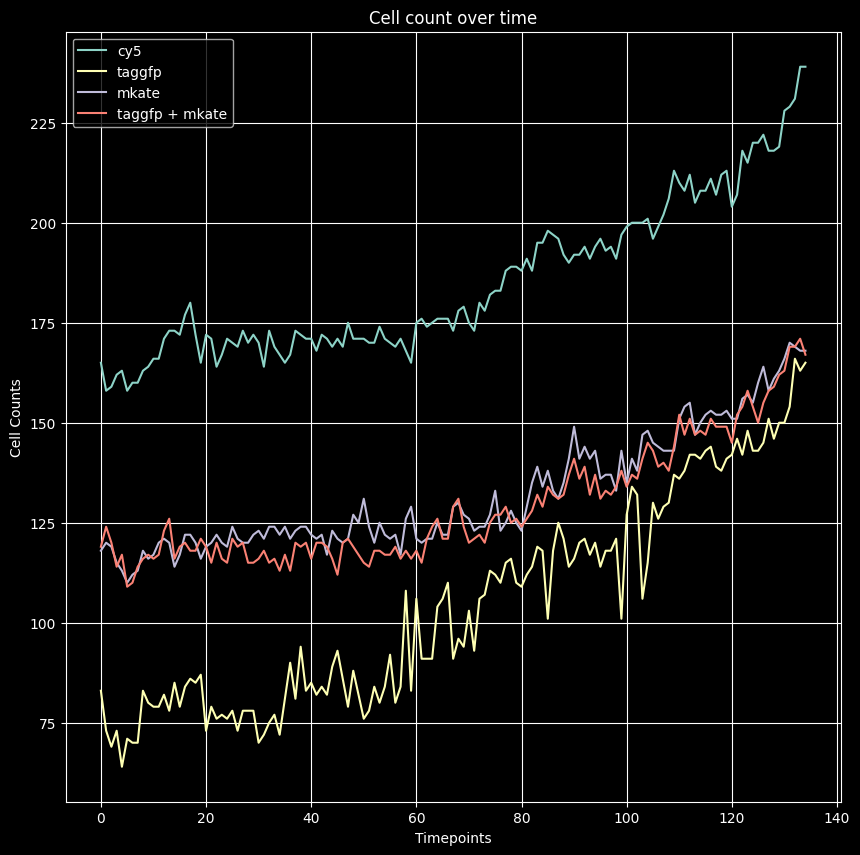

In [20]:
plt.figure(figsize=(10, 10))
for category, values in data.items():
    plt.plot(values, label=category)

plt.xlabel("Timepoints")
plt.ylabel("Cell Counts")
plt.title("Cell count over time")
plt.legend()
plt.grid(True)
plt.show()